# Local TFLite Export & Model Size Registration

Este notebook completa los artefactos que el pipeline de Vertex AI
no pudo generar (TFLite de YOLO11n y YOLO26n) y registra los
tamaños de los modelos `.pt` / `.keras` en los `experiment.json`.

**Ejecutar con el env `02_ING_MODELOS/env`** (ultralytics 8.4.9, tf 2.19.1, onnx2tf 1.28.8).

No modifica ningún código de Vertex AI.

In [1]:
import os, sys, json, shutil
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────
GCLOUD_DIR  = Path(os.path.abspath(".."))          # GoogleCloudAI/
OUTPUTS_DIR = GCLOUD_DIR / "outputs"
DATASET_DIR = GCLOUD_DIR.parent / "datasets" / "yolo26"
DATA_YAML   = str(DATASET_DIR / "data.yaml")

# src_colab from Google_Colab (read-only, no modifications)
COLAB_DIR = GCLOUD_DIR.parent / "Google_Colab"
sys.path.insert(0, str(COLAB_DIR))

# Experiment output dirs
YOLO11_DIR = OUTPUTS_DIR / "yolo11n_v1"
YOLO26_DIR = OUTPUTS_DIR / "yolo26n_v1"
MBNTS_DIR  = OUTPUTS_DIR / "MBNTv3S_ssdlite_v1"

# Model paths
YOLO11_PT = YOLO11_DIR / "train" / "weights" / "best.pt"
YOLO26_PT = YOLO26_DIR / "train" / "weights" / "best.pt"
MBNTS_KERAS = MBNTS_DIR / "MBNTv3S_ssdlite_v1_final.keras"

CLASS_NAMES = ["dog", "door", "obstacle", "person", "stair"]
IMGSZ = 224

for p, label in [(YOLO11_PT, "YOLO11n best.pt"),
                  (YOLO26_PT, "YOLO26n best.pt"),
                  (MBNTS_KERAS, "MBNTv3S .keras"),
                  (Path(DATA_YAML), "data.yaml")]:
    print(f"  {'✅' if p.exists() else '❌'} {label:25s} {p}")

  ✅ YOLO11n best.pt           /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo11n_v1/train/weights/best.pt
  ✅ YOLO26n best.pt           /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo26n_v1/train/weights/best.pt
  ✅ MBNTv3S .keras            /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/MBNTv3S_ssdlite_v1/MBNTv3S_ssdlite_v1_final.keras
  ✅ data.yaml                 /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo26/data.yaml


## 1. Registrar tamaños de los modelos Framework

In [2]:
def get_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

sizes = {
    "yolo11n_v1": get_size_mb(YOLO11_PT),
    "yolo26n_v1": get_size_mb(YOLO26_PT),
    "MBNTv3S_ssdlite_v1": get_size_mb(MBNTS_KERAS),
}

print("Model sizes (framework):")
for name, mb in sizes.items():
    print(f"  {name:30s}  {mb:.2f} MB")

# Update each experiment.json with framework_model_size_mb
for exp_name, exp_dir in [("yolo11n_v1", YOLO11_DIR),
                           ("yolo26n_v1", YOLO26_DIR),
                           ("MBNTv3S_ssdlite_v1", MBNTS_DIR)]:
    exp_path = exp_dir / "experiment.json"
    # MBNTv3S corrected version lives in corrected/
    if exp_name == "MBNTv3S_ssdlite_v1":
        corrected = exp_dir / "corrected" / "experiment.json"
        if corrected.exists():
            exp_path = corrected

    with open(exp_path) as f:
        exp = json.load(f)
    exp["results"]["framework_model_size_mb"] = round(sizes[exp_name], 2)
    with open(exp_path, "w") as f:
        json.dump(exp, f, indent=4, default=str)
    print(f"  ✅ Updated {exp_path.relative_to(OUTPUTS_DIR)}")

Model sizes (framework):
  yolo11n_v1                      5.17 MB
  yolo26n_v1                      5.10 MB
  MBNTv3S_ssdlite_v1              5.50 MB
  ✅ Updated yolo11n_v1/experiment.json
  ✅ Updated yolo26n_v1/experiment.json
  ✅ Updated MBNTv3S_ssdlite_v1/corrected/experiment.json


## 2. Export YOLO26n → TFLite INT8

In [3]:
from src_colab import export_yolo_tflite, save_export_result

yolo26_tflite_dir = YOLO26_DIR / "tflite"
yolo26_tflite_dir.mkdir(parents=True, exist_ok=True)

yolo26_export = export_yolo_tflite(
    model_path=str(YOLO26_PT),
    imgsz=IMGSZ,
    output_dir=str(yolo26_tflite_dir),
    int8=True,
    data=DATA_YAML,
)

save_export_result(yolo26_export, str(YOLO26_DIR / "export_result.json"))
print(yolo26_export.summary())

/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan o


📦 Exportando YOLO → TFLite (INT8=True)
Ultralytics 8.4.9 🚀 Python-3.10.19 torch-2.5.1 CPU (Apple M1)
YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo26n_v1/train/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirement ['protobuf>=5'] not found, attempting AutoUpdate...
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.

/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torch/onnx/symbolic_opset9.py:5385: UserWarning: Exporting aten::index operator of advanced indexing in opset 19 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


ONNX: export success ✅ 2.0s, saved as '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo26n_v1/train/weights/best.onnx' (9.2 MB)
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/notebooks/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 52.8files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...


I0000 00:00:1770585426.343599 1189523 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1770585426.347205 1189523 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Saved artifact at '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo26n_v1/train/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 224, 224, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 300, 6), dtype=tf.float32, name=None)
Captures:
  13719755360: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  13719755184: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  13719758000: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  13723842368: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  13723830576: TensorSpec(shape=(3, 3, 16, 32), dtype=tf.float32, name=None)
  13723802560: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  13774590144: TensorSpec(shape=(1, 1, 32, 32), dtype=tf.float32, name=None)
  13774592080: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  13714097776: TensorSpec(shape=(4,), dtype=tf.in

I0000 00:00:1770585517.350009 1189523 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1770585517.351062 1189523 single_machine.cc:374] Starting new session
I0000 00:00:1770585517.352085 1189523 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1770585517.352093 1189523 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
W0000 00:00:1770585518.658931 1189523 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770585518.658945 1189523 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1770585519.673019 1189523 devices.cc:76] Number of eligible GPUs (core count >= 8, com

W0000 00:00:1770585536.566130 1189523 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770585536.566153 1189523 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1770585536.603350 1189523 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1770585927.622915 1189523 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770585927.624267 1189523 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1770586308.749630 1189523 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770586308.749885 1189523 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1770587060.577914 1189523 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_for

TensorFlow SavedModel: export success ✅ 2424.9s, saved as '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo26n_v1/train/weights/best_saved_model' (31.1 MB)

TensorFlow Lite: starting export with tensorflow 2.19.1...
TensorFlow Lite: export success ✅ 0.0s, saved as '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo26n_v1/train/weights/best_saved_model/best_int8.tflite' (2.6 MB)

Export complete (2425.1s)
Results saved to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo26n_v1/train/weights
Predict:         yolo predict task=detect model=/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo26n_v1/train/weights/best_saved_model/best_int8.tflite imgsz=224 int8
Validate:        yolo val task=detect model=/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo26n_v1/train/weights/best_saved_model/best_int8.tflite imgsz=224 data=/tmp/training/datasets/yolo26/data.yaml int8 
Visualize

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 3. Export YOLO11n → TFLite INT8

In [4]:
yolo11_tflite_dir = YOLO11_DIR / "tflite"
yolo11_tflite_dir.mkdir(parents=True, exist_ok=True)

yolo11_export = export_yolo_tflite(
    model_path=str(YOLO11_PT),
    imgsz=IMGSZ,
    output_dir=str(yolo11_tflite_dir),
    int8=True,
    data=DATA_YAML,
)

save_export_result(yolo11_export, str(YOLO11_DIR / "export_result.json"))
print(yolo11_export.summary())


📦 Exportando YOLO → TFLite (INT8=True)
Ultralytics 8.4.9 🚀 Python-3.10.19 torch-2.5.1 CPU (Apple M1)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo11n_v1/train/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 9, 1029) (5.2 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.1...
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo26/data.yaml'
Fast image access ✅ (ping: 0.0±0.0 ms, read: 168.5±94.7 MB/s, size: 48.6 KB)
Scanning /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo26/valid/labels.cache... 2066 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2066/2066 98.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 4, len(boxes) = 4120. To resolve this only boxes will be used and all

I0000 00:00:1770588091.590782 1189523 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1770588091.592580 1189523 single_machine.cc:374] Starting new session
I0000 00:00:1770588091.593626 1189523 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1770588091.593636 1189523 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
W0000 00:00:1770588092.644979 1189523 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770588092.644995 1189523 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1770588093.514719 1189523 devices.cc:76] Number of eligible GPUs (core count >= 8, com

W0000 00:00:1770588101.003568 1189523 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770588101.004273 1189523 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1770588478.684770 1189523 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770588478.685441 1189523 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1770588854.571354 1189523 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770588854.571856 1189523 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1770589607.685749 1189523 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770589607.686679 1189523 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


TensorFlow SavedModel: export success ✅ 2299.9s, saved as '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo11n_v1/train/weights/best_saved_model' (33.3 MB)

TensorFlow Lite: starting export with tensorflow 2.19.1...
TensorFlow Lite: export success ✅ 0.0s, saved as '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo11n_v1/train/weights/best_saved_model/best_int8.tflite' (2.7 MB)

Export complete (2300.1s)
Results saved to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo11n_v1/train/weights
Predict:         yolo predict task=detect model=/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo11n_v1/train/weights/best_saved_model/best_int8.tflite imgsz=224 int8
Validate:        yolo val task=detect model=/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo11n_v1/train/weights/best_saved_model/best_int8.tflite imgsz=224 data=/tmp/training/datasets/yolo26/data.yaml int8 
Visualize

## 4. Evaluate TFLite models on test split

In [8]:
# _parse_tflite_outputs expects MobileNet SSD (3 outputs: obj/cls/bbox),
# but YOLO TFLite has a single output tensor → 0 detections parsed.
# Fix: use Ultralytics native val() which handles its own TFLite format.

from ultralytics import YOLO as _YOLO
from src_colab import EvaluationResults, save_evaluation
import numpy as np

results = {}

for exp_name, export_res in [("yolo26n_v1", yolo26_export),
                              ("yolo11n_v1", yolo11_export)]:
    if not export_res.tflite_path or not os.path.exists(export_res.tflite_path):
        print(f"⚠️  {exp_name}: TFLite no disponible, saltando evaluación.")
        results[exp_name] = None
        continue

    print(f"\n{'='*60}")
    print(f"Evaluando TFLite (Ultralytics val): {exp_name}")
    print(f"{'='*60}")

    tfl = _YOLO(export_res.tflite_path)
    metrics = tfl.val(
        data=DATA_YAML, imgsz=IMGSZ, split="test",
        conf=0.25, iou=0.5, verbose=True,
        project=str(OUTPUTS_DIR / exp_name), name="tflite_val",
        exist_ok=True,
    )

    # Convert Ultralytics DetMetrics → EvaluationResults
    ev = EvaluationResults()
    ev.model_name = f"{exp_name}_tflite"
    ev.family = "tflite"
    ev.split = "test"
    ev.class_names = CLASS_NAMES
    ev.mAP50 = float(metrics.box.map50)
    ev.mAP50_95 = float(metrics.box.map)
    ev.precision = float(metrics.box.mp)
    ev.recall = float(metrics.box.mr)
    ev.f1 = (2 * ev.precision * ev.recall / (ev.precision + ev.recall)
             if (ev.precision + ev.recall) > 0 else 0.0)

    for i, cls_name in enumerate(CLASS_NAMES):
        if i < len(metrics.box.ap50):
            ev.per_class_ap50[cls_name] = float(metrics.box.ap50[i])

    if hasattr(metrics, 'speed') and metrics.speed:
        ev.avg_inference_ms = metrics.speed.get('inference', 0.0)

    exp_dir = OUTPUTS_DIR / exp_name
    save_evaluation(ev, str(exp_dir / "tflite_test_evaluation.json"))
    results[exp_name] = ev

    print(f"\n  mAP@50={ev.mAP50:.4f}  mAP@50-95={ev.mAP50_95:.4f}")
    print(f"  P={ev.precision:.4f}  R={ev.recall:.4f}  F1={ev.f1:.4f}")
    for cls_name, ap in sorted(ev.per_class_ap50.items()):
        print(f"    {cls_name:12s}  AP@50={ap:.4f}")


Evaluando TFLite (Ultralytics val): yolo26n_v1
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Ultralytics 8.4.9 🚀 Python-3.10.19 torch-2.5.1 CPU (Apple M1)
Loading /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo26n_v1/tflite/best_int8.tflite for TensorFlow Lite inference...
Setting batch=1 input of shape (1, 3, 224, 224)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 113.8±33.4 MB/s, size: 40.3 KB)
val: Scanning /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo26/test/labels... 2066 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2066/2066 4.4Kit/s 0.5s0.1s
val: New cache created: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo26/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 9, len(boxes) = 4096. To resolve this only boxes will be used and all segments will

## 5. Update experiment.json with TFLite results

In [9]:
for exp_name, export_res in [("yolo26n_v1", yolo26_export),
                              ("yolo11n_v1", yolo11_export)]:
    exp_path = OUTPUTS_DIR / exp_name / "experiment.json"
    with open(exp_path) as f:
        exp = json.load(f)

    r = exp["results"]

    # Export info
    r["tflite_size_mb"] = export_res.size_mb
    r["tflite_esp32_ok"] = export_res.esp32_compatible

    # TFLite evaluation metrics
    ev = results.get(exp_name)
    if ev is not None:
        r["tflite_test_mAP50"] = ev.mAP50
        r["tflite_test_mAP50_95"] = ev.mAP50_95
        r["tflite_test_precision"] = ev.precision
        r["tflite_test_recall"] = ev.recall
        r["tflite_test_f1"] = ev.f1
        r["tflite_test_per_class_ap50"] = ev.per_class_ap50

    with open(exp_path, "w") as f:
        json.dump(exp, f, indent=4, default=str)
    print(f"✅ {exp_name}/experiment.json updated  (tflite_size={export_res.size_mb:.2f} MB)")

✅ yolo26n_v1/experiment.json updated  (tflite_size=2.55 MB)
✅ yolo11n_v1/experiment.json updated  (tflite_size=2.68 MB)


## 6. Comparison table: all 3 models

In [30]:
# Load all experiment.json
experiments = {}
for name, path in [
    ("YOLO11n", YOLO11_DIR / "experiment.json"),
    ("YOLO26n", YOLO26_DIR / "experiment.json"),
    ("MBNTv3S", MBNTS_DIR / "corrected" / "experiment.json"),
]:
    with open(path) as f:
        experiments[name] = json.load(f)["results"]

def fmt(v, decimals=4):
    if isinstance(v, float):
        return f"{v:.{decimals}f}" if v > 0 else "—"
    return str(v) if v else "—"

# ── Framework comparison ──
print("\n" + "="*75)
print("  FRAMEWORK (test split)")
print("="*75)
print(f"{'Metric':<25s} {'YOLO11n':>14s} {'YOLO26n':>14s} {'MBNTv3S':>14s}")
print("-"*75)
for metric in ["test_mAP50", "test_mAP50_95", "test_precision", "test_recall", "test_f1",
               "framework_model_size_mb"]:
    vals = [experiments[m].get(metric, 0) for m in ["YOLO11n", "YOLO26n", "MBNTv3S"]]
    d = 2 if "size" in metric else 4
    print(f"  {metric:<23s} {fmt(vals[0], d):>14s} {fmt(vals[1], d):>14s} {fmt(vals[2], d):>14s}")

# ── Per-class AP@50 ──
print(f"\n  Per-class AP@50 (test):")
for cls in CLASS_NAMES:
    vals = [experiments[m].get("test_per_class_ap50", {}).get(cls, 0)
            for m in ["YOLO11n", "YOLO26n", "MBNTv3S"]]
    print(f"    {cls:<12s} {fmt(vals[0]):>14s} {fmt(vals[1]):>14s} {fmt(vals[2]):>14s}")

# ── TFLite comparison ──
print("\n" + "="*75)
print("  TFLITE INT8 (test split)")
print("="*75)
print(f"{'Metric':<25s} {'YOLO11n':>14s} {'YOLO26n':>14s} {'MBNTv3S':>14s}")
print("-"*75)
for metric in ["tflite_size_mb", "tflite_esp32_ok",
               "tflite_test_mAP50", "tflite_test_mAP50_95",
               "tflite_test_precision", "tflite_test_recall", "tflite_test_f1"]:
    vals = [experiments[m].get(metric, 0) for m in ["YOLO11n", "YOLO26n", "MBNTv3S"]]
    d = 2 if "size" in metric else 4
    print(f"  {metric:<23s} {fmt(vals[0], d):>14s} {fmt(vals[1], d):>14s} {fmt(vals[2], d):>14s}")


  FRAMEWORK (test split)
Metric                           YOLO11n        YOLO26n        MBNTv3S
---------------------------------------------------------------------------
  test_mAP50                      0.8074         0.7932         0.3263
  test_mAP50_95                   0.5982         0.5978              —
  test_precision                  0.8367         0.8228         0.1583
  test_recall                     0.7171         0.6989         0.5245
  test_f1                         0.7723         0.7558         0.2432
  framework_model_size_mb           5.17           5.10           5.50

  Per-class AP@50 (test):
    dog                  0.7875         0.7643         0.3943
    door                 0.9043         0.9045         0.3711
    obstacle             0.7463         0.7465         0.1852
    person               0.7456         0.7113         0.1056
    stair                0.8534         0.8392         0.5751

  TFLITE INT8 (test split)
Metric                           YOL

## 7. Visual comparison — Framework vs TFLite (1 image per class)

In [38]:
import random, glob
from collections import defaultdict

# random.seed(42)  # descomentar para resultados reproducibles

# ── Build class → image index from test labels ──────────────────
test_labels_dir = DATASET_DIR / "test" / "labels"
test_images_dir = DATASET_DIR / "test" / "images"

class_to_images = defaultdict(list)
for lbl_path in sorted(test_labels_dir.glob("*.txt")):
    with open(lbl_path) as f:
        classes_in_file = {int(line.split()[0]) for line in f if line.strip()}
    stem = lbl_path.stem
    # Find the actual image (jpg/png)
    for ext in (".jpg", ".jpeg", ".png"):
        img_path = test_images_dir / (stem + ext)
        if img_path.exists():
            for cid in classes_in_file:
                class_to_images[cid].append(str(img_path))
            break

# ── Pick 1 random image per class ───────────────────────────────
selected = {}
for cid, cname in enumerate(CLASS_NAMES):
    pool = class_to_images.get(cid, [])
    if pool:
        selected[cid] = random.choice(pool)
        print(f"  {cname:12s} (class {cid}) → {Path(selected[cid]).name}")
    else:
        print(f"  ⚠️  {cname} — no test images found")

print(f"\n  {len(selected)} images selected for visual comparison")

  dog          (class 0) → img_001096_jpg.rf.264dc6e10863f54c55edad74dfa1fac4.jpg
  door         (class 1) → img_006873_jpg.rf.73c5de0a83c2e48ef48102f231230281.jpg
  obstacle     (class 2) → img_001377_jpg.rf.1aff26c95908f4b2da00788550b0b8e6.jpg
  person       (class 3) → img_009116_jpg.rf.8c0540465549e41d6f55fc0407c3dba8.jpg
  stair        (class 4) → aug_001758_jpg.rf.28e168ae7b21b0ee7a97b282941df5ab.jpg

  5 images selected for visual comparison


Loading MobileNet .keras model …
  ✅ Loaded with keras (Keras 3)
  ✅ YOLO11n TFL: best_int8.tflite
  ✅ YOLO26n TFL: best_int8.tflite
  ✅ MBNTv3S TFL: MBNTv3S_ssdlite_v1_int8.tflite

Running inference with 6 model variants …
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo11n_v1/tflite/best_int8.tflite for TensorFlow Lite inference...
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/yolo26n_v1/tflite/best_int8.tflite for TensorFlow Lite inference...
  MBNTv3S post-filter (conf≥0.4): FW=1 dets, TFL=4 dets

✅ Saved → /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/

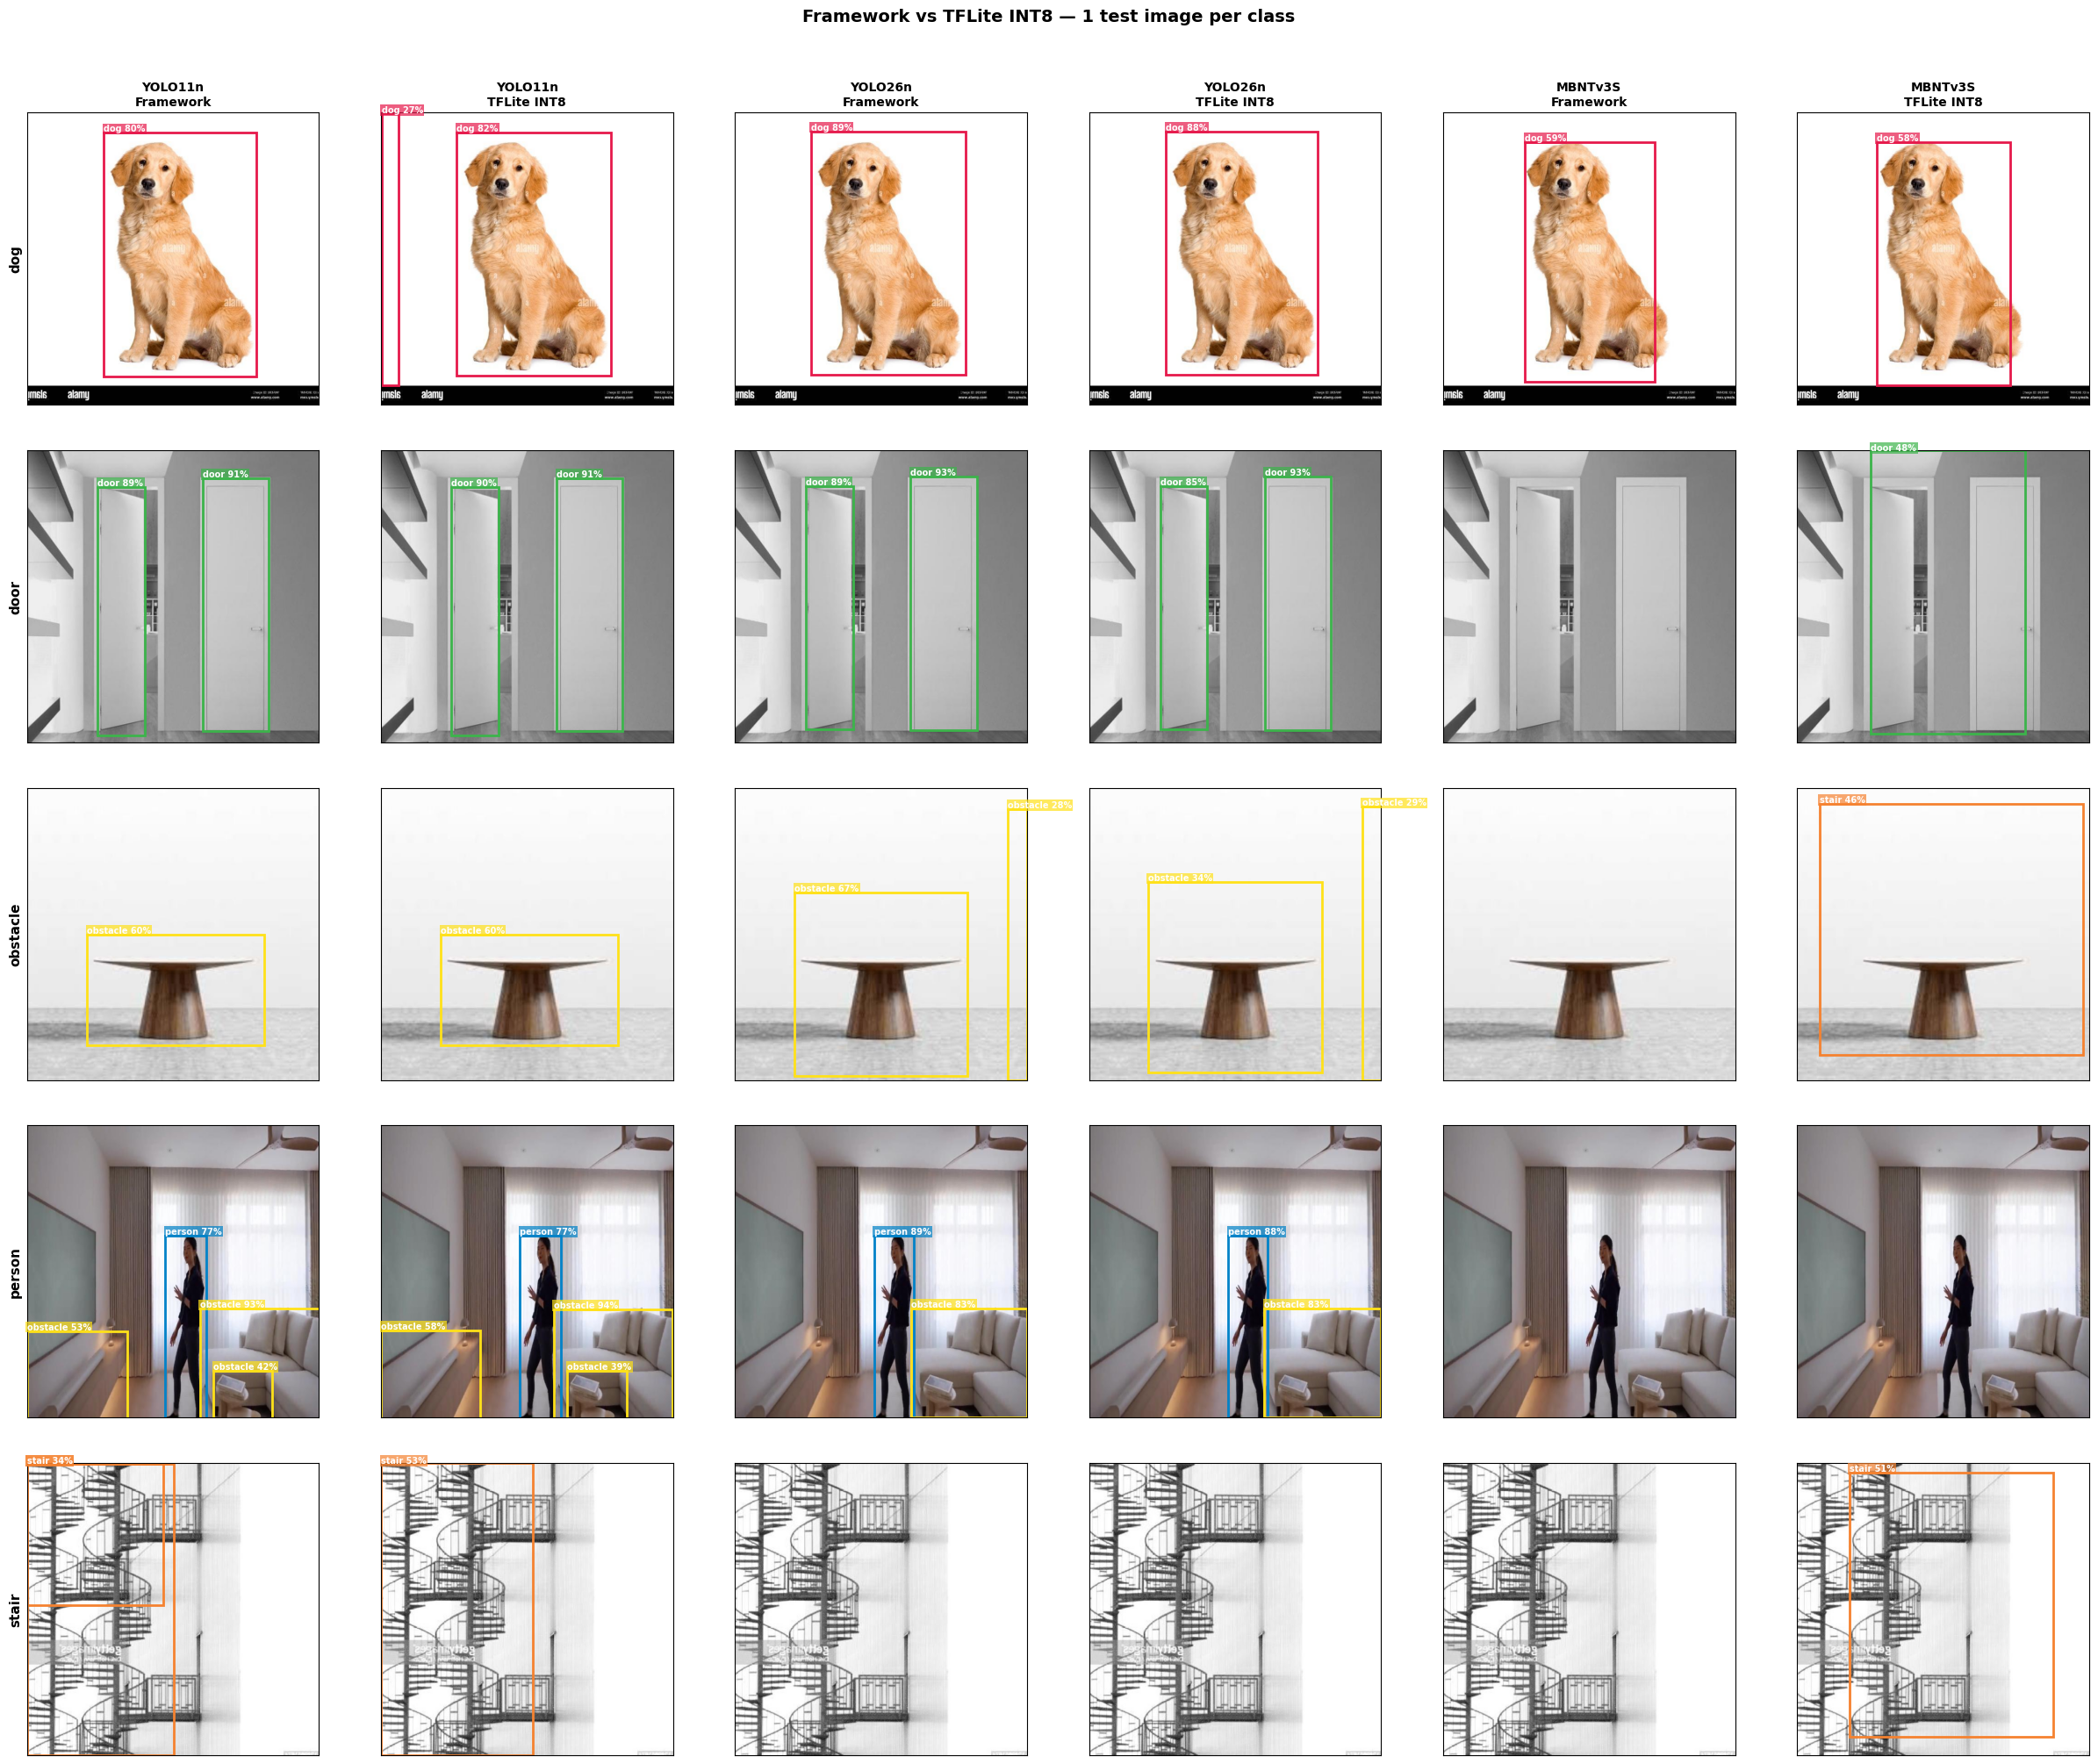

In [39]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.max_open_warning'] = 0

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
from IPython.display import display
from src_colab import (
    predict_yolo, predict_mobilenet, predict_tflite, DetectedObject,
)
from ultralytics import YOLO as _YOLO

# ── Color palette (one per class) ───────────────────────────────
_COLORS = [
    (230,  25,  75),  # red      – dog
    ( 60, 180,  75),  # green    – door
    (255, 225,  25),  # yellow   – obstacle
    (  0, 130, 200),  # blue     – person
    (245, 130,  48),  # orange   – stair
]

def _draw_dets(ax, dets, img_w, img_h, lw=2):
    """Draw DetectedObject boxes on an axes."""
    for d in dets:
        x1, y1, x2, y2 = d.bbox                       # normalised
        x1, y1, x2, y2 = x1*img_w, y1*img_h, x2*img_w, y2*img_h
        c = tuple(v/255 for v in _COLORS[d.class_id % len(_COLORS)])
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=lw, edgecolor=c, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, max(y1-3, 0),
                f"{d.class_name} {d.confidence:.0%}",
                fontsize=7, color="white", weight="bold",
                bbox=dict(facecolor=c, alpha=0.7, pad=1, edgecolor="none"))

def _filter_by_confidence(preds_list, min_conf=0.25):
    """Post-filter detections by combined confidence score.

    predict_mobilenet / predict_tflite filter only by objectness,
    so many low-confidence boxes survive NMS.  This helper removes
    detections whose combined score (obj × class_prob) < min_conf.
    """
    return [[d for d in dets if d.confidence >= min_conf]
            for dets in preds_list]

# ── Predict with YOLO TFLite via Ultralytics ────────────────────
def _yolo_tflite_predict(tflite_path, img_paths, class_names,
                         imgsz=224, conf=0.25, iou=0.45):
    """Wrap YOLO(tflite).predict() → List[List[DetectedObject]]."""
    model = _YOLO(tflite_path)
    all_dets = []
    for img_path in img_paths:
        res = model.predict(img_path, imgsz=imgsz, conf=conf, iou=iou,
                            verbose=False)
        dets = []
        for r in res:
            for box in r.boxes:
                cid = int(box.cls)
                dets.append(DetectedObject(
                    class_id=cid,
                    class_name=class_names[cid] if cid < len(class_names) else str(cid),
                    confidence=float(box.conf),
                    bbox=tuple(box.xyxyn[0].tolist()),
                ))
        all_dets.append(dets)
    return all_dets

# ── Load MobileNet model (Keras 3) ──────────────────────────────
print("Loading MobileNet .keras model …")
try:
    import keras
    mbn_model = keras.models.load_model(str(MBNTS_KERAS), compile=False)
    print("  ✅ Loaded with keras (Keras 3)")
except Exception as e1:
    print(f"  keras load failed: {e1}")
    import tensorflow as tf
    mbn_model = tf.keras.models.load_model(str(MBNTS_KERAS), compile=False)
    print("  ✅ Loaded with tf.keras fallback")

# ── TFLite paths ────────────────────────────────────────────────
YOLO11_TFL = str(YOLO11_DIR / "tflite" / "best_int8.tflite")
YOLO26_TFL = str(YOLO26_DIR / "tflite" / "best_int8.tflite")
MBNTS_TFL  = str(MBNTS_DIR / "tflite" / "MBNTv3S_ssdlite_v1_int8.tflite")

for p, l in [(YOLO11_TFL, "YOLO11n TFL"), (YOLO26_TFL, "YOLO26n TFL"),
             (MBNTS_TFL, "MBNTv3S TFL")]:
    print(f"  {'✅' if os.path.exists(p) else '❌'} {l}: {Path(p).name}")

# ── Run inference for every (model_variant, image) ──────────────
img_paths_ordered = [selected[cid] for cid in sorted(selected)]
n_imgs = len(img_paths_ordered)

model_labels = [
    "YOLO11n\nFramework", "YOLO11n\nTFLite INT8",
    "YOLO26n\nFramework", "YOLO26n\nTFLite INT8",
    "MBNTv3S\nFramework", "MBNTv3S\nTFLite INT8",
]

# Prepare MobileNet input (numpy [B,H,W,3] float32 in [0,1])
mbn_imgs = []
for ip in img_paths_ordered:
    img = Image.open(ip).convert("RGB").resize((IMGSZ, IMGSZ))
    mbn_imgs.append(np.array(img, dtype=np.float32) / 255.0)
mbn_batch = np.stack(mbn_imgs)

print("\nRunning inference with 6 model variants …")
preds = {}

# ── MobileNet NMS IoU threshold (lower = suppress more overlapping boxes) ──
MBN_IOU = 0.35
# predict_mobilenet / predict_tflite only filter by objectness head,
# so many low combined-score boxes survive NMS. Apply post-filter.
MBN_CONF = 0.40

preds["YOLO11n FW"]  = predict_yolo(str(YOLO11_PT),  img_paths_ordered, imgsz=IMGSZ)
preds["YOLO11n TFL"] = _yolo_tflite_predict(YOLO11_TFL, img_paths_ordered, CLASS_NAMES, imgsz=IMGSZ)
preds["YOLO26n FW"]  = predict_yolo(str(YOLO26_PT),  img_paths_ordered, imgsz=IMGSZ)
preds["YOLO26n TFL"] = _yolo_tflite_predict(YOLO26_TFL, img_paths_ordered, CLASS_NAMES, imgsz=IMGSZ)
preds["MBNTv3S FW"]  = predict_mobilenet(mbn_model, mbn_batch, CLASS_NAMES, imgsz=IMGSZ,
                                          iou_threshold=MBN_IOU)
preds["MBNTv3S TFL"], _ = predict_tflite(MBNTS_TFL, mbn_batch, CLASS_NAMES,
                                          iou_threshold=MBN_IOU)


preds["MBNTv3S FW"]  = _filter_by_confidence(preds["MBNTv3S FW"],  min_conf=MBN_CONF)
preds["MBNTv3S TFL"] = _filter_by_confidence(preds["MBNTv3S TFL"], min_conf=MBN_CONF)
print(f"  MBNTv3S post-filter (conf≥{MBN_CONF}): "
      f"FW={sum(len(d) for d in preds['MBNTv3S FW'])} dets, "
      f"TFL={sum(len(d) for d in preds['MBNTv3S TFL'])} dets")

# ── Build the 5-row × 6-col grid ────────────────────────────────
fig, axes = plt.subplots(n_imgs, 6, figsize=(6*4, n_imgs*4))
if n_imgs == 1:
    axes = axes[np.newaxis, :]

pred_keys = ["YOLO11n FW", "YOLO11n TFL",
             "YOLO26n FW", "YOLO26n TFL",
             "MBNTv3S FW", "MBNTv3S TFL"]

for row, cid in enumerate(sorted(selected)):
    img = Image.open(selected[cid]).convert("RGB")
    img_w, img_h = img.size
    img_np = np.array(img)

    for col, key in enumerate(pred_keys):
        ax = axes[row, col]
        ax.imshow(img_np)
        _draw_dets(ax, preds[key][row], img_w, img_h)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(model_labels[col], fontsize=10, weight="bold")
        if col == 0:
            ax.set_ylabel(CLASS_NAMES[cid], fontsize=11, weight="bold", rotation=90)

fig.suptitle("Framework vs TFLite INT8 — 1 test image per class",
             fontsize=14, weight="bold", y=1.01)
fig.tight_layout()

save_path = str(OUTPUTS_DIR / "fw_vs_tflite_visual_comparison.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"\n✅ Saved → {save_path}")
display(fig)
plt.close(fig)